In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\user\Downloads\ecommerce_messy_dataset.csv")
df.head()

,Order_ID,Customer_ID,Product_ID,Product_Name,Category,Order_Date,Quantity,Price,Revenue,Discount_Percent,Payment_Method,City,Customer_Rating,Delivery_Days,Returned,Stock_Level
0,ORD100000,CUST2824,PROD125,Social Watch,Home,2025-09-20,2,454.19,908.38,NaN,Credit Card,Hyderabad,NaN,15,Yes,302
1,ORD100001,CUST7912,PROD132,Phone Phone,Electronics,2025-01-26,2,473.0,946.00,20.0,Credit Card,Kolkata,2.0,12,No,112
2,ORD100002,CUST8359,PROD703,Writer Cream,Toys,2024-10-16,1,1520.03,1520.03,5.0,Debit Card,Bangalore,3.0,3,Yes,490
3,ORD100003,CUST6514,PROD204,Clear Phone,Beauty,2025-05-13,1,724.37,724.37,10.0,Net Banking,Bangalore,1.0,12,No,274
4,ORD100004,CUST3045,PROD487,Better Phone,Sports,2025-07-15,3,1660.52,4981.56,20.0,COD,Kolkata,2.0,12,Yes,23


In [4]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Product_ID', 'Product_Name', 'Category',
       'Order_Date', 'Quantity', 'Price', 'Revenue', 'Discount_Percent',
       'Payment_Method', 'City', 'Customer_Rating', 'Delivery_Days',
       'Returned', 'Stock_Level'],
      dtype='str')

In [5]:
df.describe()

,Revenue,Discount_Percent,Customer_Rating,Delivery_Days,Stock_Level
count,10050.000000,8533.000000,8340.000000,10300.000000,10300.000000
mean,3655.268379,10.024610,3.021223,8.022427,247.455243
std,12523.216329,7.063977,1.420527,4.341476,144.559358
min,10.510000,0.000000,1.000000,1.000000,0.000000
25%,1085.990000,5.000000,2.000000,4.000000,121.000000
50%,2341.910000,10.000000,3.000000,8.000000,246.000000
75%,4477.057500,15.000000,4.000000,12.000000,373.000000
max,470847.500000,20.000000,5.000000,15.000000,500.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10300 non-null  str    
 1   Customer_ID       10300 non-null  str    
 2   Product_ID        10300 non-null  str    
 3   Product_Name      10300 non-null  str    
 4   Category          10300 non-null  str    
 5   Order_Date        10300 non-null  str    
 6   Quantity          10300 non-null  str    
 7   Price             10059 non-null  str    
 8   Revenue           10050 non-null  float64
 9   Discount_Percent  8533 non-null   float64
 10  Payment_Method    10300 non-null  str    
 11  City              10050 non-null  str    
 12  Customer_Rating   8340 non-null   float64
 13  Delivery_Days     10300 non-null  int64  
 14  Returned          10300 non-null  str    
 15  Stock_Level       10300 non-null  int64  
dtypes: float64(3), int64(2), str(11)
memory usage: 1.3 

# Change The Data Types

<!-- Change The Data Types -->


In [7]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [33]:
df['Order_ID'] = df['Order_ID'].str.replace('ORD', '')
df['Order_ID'] = pd.to_numeric(df['Order_ID'])

In [ ]:
df['Product_ID'] = df['Product_ID'].str.replace('PROD', '')
df['Product_ID'] = pd.to_numeric(df['Product_ID'])

In [ ]:
df['Customer_ID'] = df['Customer_ID'].str.replace("CUST","")
df['Customer_ID']=pd.to_numeric(df['Customer_ID'])

# 
Remove Duplicates

In [9]:
df = df.drop_duplicates()

# Check NULL Values 

In [10]:
df.isnull().sum()

Order_ID               0
Customer_ID            0
Product_ID             0
Product_Name           0
Category               0
Order_Date             0
Quantity               0
Price                241
Revenue              250
Discount_Percent    1727
Payment_Method         0
City                 250
Customer_Rating     1921
Delivery_Days          0
Returned               0
Stock_Level            0
dtype: int64

# Fill the missing values

In [11]:
df['City'] = df['City'].fillna("unknown")

In [12]:
df['Customer_Rating'] = df['Customer_Rating'].fillna(df['Customer_Rating'].mean())

In [13]:
df['Revenue'] =df['Revenue'] .fillna(df['Revenue'].median())

In [30]:
df['Discount_Percent'] = df['Discount_Percent'].fillna(df['Discount_Percent'].median())

# NET REVENUE

In [15]:
# Total Sales Before  Discount
total_sales = df['Revenue'].sum()
total_sales

np.float64(36731556.92)

In [16]:
# Total Revenue After Discount
df['Net_Revenue'] = df['Revenue'] * (1 - df['Discount_Percent'] / 100)

In [17]:
# Total Net Revenue 
Net_Revenue = df['Net_Revenue'].sum()
Net_Revenue

np.float64(27560014.571)

In [18]:
total_orders = df['Order_ID'].nunique()
total_orders

10000

In [19]:
avg_rating = df['Customer_Rating'].mean()
avg_rating

np.float64(3.0222548300317924)

In [20]:
avg_order_value = Net_Revenue / total_orders
avg_order_value

np.float64(2756.0014570999997)

# Top Categories By Revenue

In [48]:
top_category =df.groupby("Category")['Revenue'].sum().sort_values(ascending = False).head(5)
top_category

Category
Electronics    6334761.14
Sports         5250709.93
Home           5212053.41
Toys           5203056.34
Fashion        5155371.25
Name: Revenue, dtype: float64

# Top 10 Products By Revenue

In [22]:
top_products = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending = False).head(10)
top_products


Product_Name
Yes Laptop         477410.45
Wrong Laptop       472200.51
Talk Cream         442192.34
Rich Cream         359863.18
Continue Bottle    299047.72
Everyone Watch     289168.90
Seven Watch        266945.01
Receive Shoes      223316.08
Sound Bottle       200503.12
Doctor Phone       195869.83
Name: Revenue, dtype: float64

# Top City By Revenue

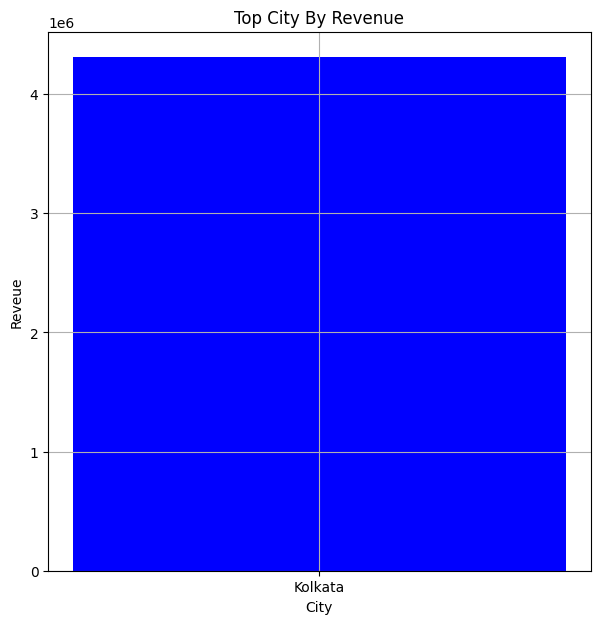

In [31]:
top_cities = df[df['City'] !='unknown'].groupby('City')['Net_Revenue'].sum().sort_values(ascending=False).head(1)
top_cities

plt.figure(figsize=(7,7))
plt.bar(
    top_cities.index,
    top_cities.values,
    color='Blue',
     )
plt.title('Top City By Revenue')
plt.xlabel('City')
plt.ylabel('Reveue')
plt.grid(True)
plt.show()

# Monthly Sales Trend

In [24]:
df['Month']= df['Order_Date'].dt.month

In [25]:
monthly_sales_trend = df.groupby('Month')['Revenue'].sum()
monthly_sales_trend

Month
1     2950056.09
2     2668639.70
3     2868017.81
4     3016872.14
5     3490793.45
6     2891242.17
7     3501815.83
8     2957046.49
9     3310129.95
10    2828985.91
11    3057728.01
12    3190229.37
Name: Revenue, dtype: float64

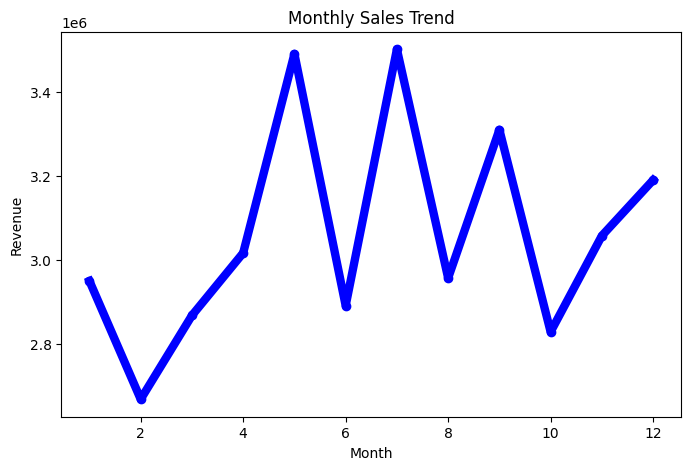

In [26]:
plt.figure(figsize=(8,5))
plt.plot(monthly_sales_trend,
    color='blue',
    marker='o',
    linestyle='-',
    linewidth=6
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

# Top Customers By Revenue

In [45]:
top_customers = df.groupby('Customer_ID')['Revenue'].sum()

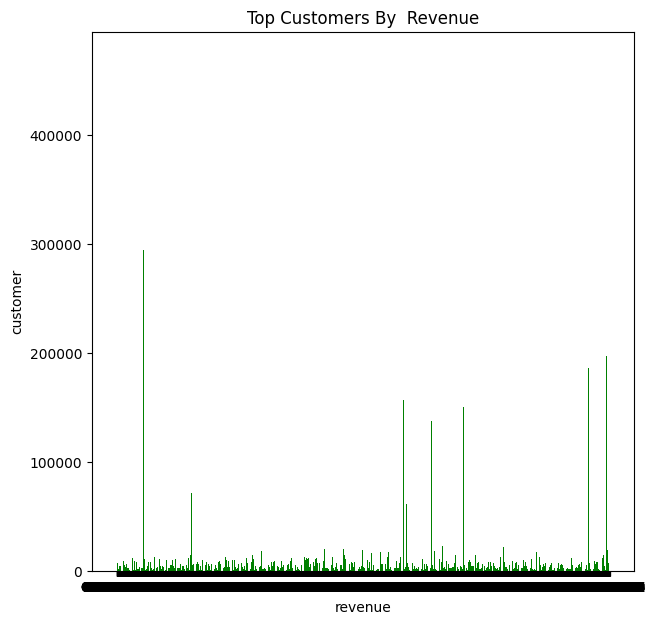

In [46]:
plt.figure(figsize=(7,7))
plt.bar(
     top_customers.index ,
     top_customers.values,
     color = 'Green'
)
plt.title('Top Customers By  Revenue')
plt.xlabel('revenue')
plt.ylabel('customer')
plt.show()


In [47]:
df.head()

,Order_ID,Customer_ID,Product_ID,Product_Name,Category,Order_Date,Quantity,Price,Revenue,Discount_Percent,Payment_Method,City,Customer_Rating,Delivery_Days,Returned,Stock_Level,Discount,Net_Revenue,Month,rating_spend
0,100000,CUST2824,PROD125,Social Watch,Home,2025-09-20,2,454.19,908.38,10.0,Credit Card,Hyderabad,3.022255,15,Yes,302,10.0,NaN,9,NaN
1,100001,CUST7912,PROD132,Phone Phone,Electronics,2025-01-26,2,473.0,946.00,20.0,Credit Card,Kolkata,2.000000,12,No,112,20.0,756.8000,1,6477924.27
2,100002,CUST8359,PROD703,Writer Cream,Toys,2024-10-16,1,1520.03,1520.03,5.0,Debit Card,Bangalore,3.000000,3,Yes,490,5.0,1444.0285,10,5823899.72
3,100003,CUST6514,PROD204,Clear Phone,Beauty,2025-05-13,1,724.37,724.37,10.0,Net Banking,Bangalore,1.000000,12,No,274,10.0,651.9330,5,6138894.66
4,100004,CUST3045,PROD487,Better Phone,Sports,2025-07-15,3,1660.52,4981.56,20.0,COD,Kolkata,2.000000,12,Yes,23,20.0,3985.2480,7,5735947.77


# Rating VS Total Spend

In [35]:
df['rating_spend'] = df.groupby('Customer_Rating')['Revenue'].sum()

<Axes: xlabel='Customer_Rating', ylabel='Revenue'>

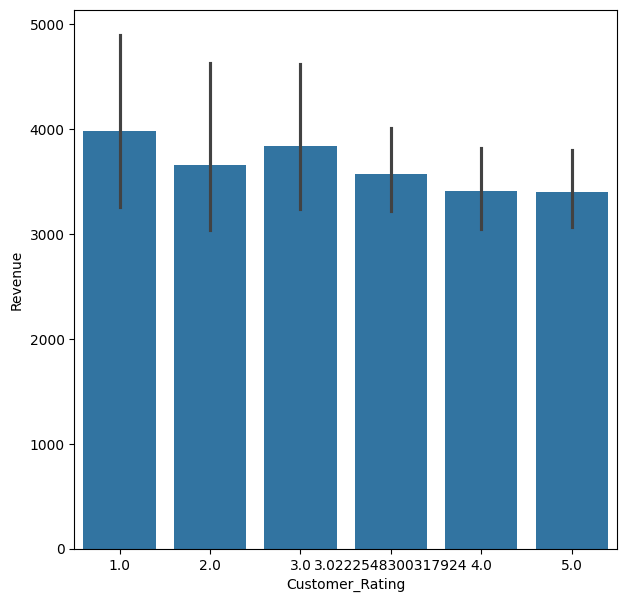

In [40]:
plt.figure(figsize=(7,7))
sns.barplot(x='Customer_Rating',y='Revenue',data =df)


# KEY INSIGHTS 

1. Heavy discounting reduced revenue significantly (~25%).
2. The Electronics category contributes 38% of total revenue.
3. Top 10 customers contributed 27% of total revenue.
4. Sales peak strongly during May–July seasons.
5. Average customer satisfaction is only moderate (3.02/5).
6. Laptops are highly demanded and strongly recommended by users, indicating high customer satisfaction.





# Recommendations

1. Test optimal discount ranges (10–20%)
2. Launch premium electronics products
3. Collect customer feedback regularly
4. Prepare better for seasonal demand
